# Разработка алгоритма расчета состояния прибытия пожарных подразделений к зданиям

In [12]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import osmnx as ox


from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat
from genesis.utils import timing
import matplotlib.pyplot as plt
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.swiss_knife import MSF, DELAY_TIME

from fire_units.metrics import Demand


In [53]:
# Загрузка графа, полигона границ и зданий
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")
buildings = gpd.read_file("tests/data/buildings.gpkg", layer="здания")
# buildings.head()

## Разработка

In [54]:
nodes_gdf = ox.project_gdf(ox.graph_to_gdfs(G, edges=False))
nodes_gdf['node'] = nodes_gdf.index
buildings = ox.project_gdf(buildings)

In [55]:
buildings_new = buildings.sjoin_nearest(nodes_gdf[['geometry']], max_distance=100)
buildings_new.rename(columns={'index_right': 'node'}, inplace=True)
buildings_new.head(2)

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,demand,geometry,node
0,114435873,NaN,NaN,Многоквартирный жилой дом,улица Ленинского Комсомола,2,9,NaN,0.014152,"POLYGON ((521283.901 6220143.312, 521291.376 6...",9085465307
1,114435874,NaN,NaN,Торговое здание,улица Ленинского Комсомола,NaN,NaN,NaN,0.003726,"POLYGON ((521066.656 6219874.938, 521059.407 6...",9085465281


C:\Users\obsid\AppData\Local\Temp\ipykernel_7988\1152995964.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


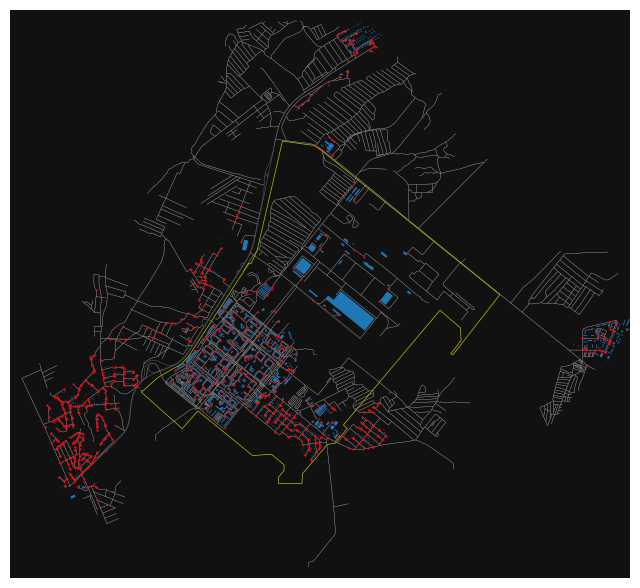

In [59]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
nodes_gdf2 = ox.graph_to_gdfs(G, edges=False)
nodes_gdf2.loc[buildings_new['node']].plot(ax=ax, c='r', markersize=0.2)
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

In [87]:
class FireDemandSatisfyState(FirstArrivalUnitState):
    def __init__(self, state_algorithm=MSF, weight='travel_time', delay=DELAY_TIME, **kwargs):
        super().__init__(state_algorithm, weight, delay, **kwargs)

    def __call__(self,
                 env: nx.MultiDiGraph,
                 points: dict,
                 buildings: gpd.GeoDataFrame,
                 buildings_node_id_field: str = 'node',
                 buildings_demand_field: str = 'demand',
                 area=None,
                 **kwargs):

        # print(1, points)

        # Вот это будет вызывать базовый алгоритм:
        times, nearest = super().__call__(env, points, area, **kwargs)
        arrival_state = pd.concat([times, nearest], axis=1)

        # print(2, len(arrival_state))

        # здесь сопоставляем building и times
        merged_df = pd.merge(buildings, arrival_state, left_on=buildings_node_id_field, right_index=True)  # здесь подумать! #, how='left')

        # Расчет собственно состояния удовлетворенности спроса
        return merged_df[buildings_demand_field] / merged_df['times'], merged_df['nearest']   #, merged_df['times']

        

nodes_list = list(G.nodes())
points = {
    nodes_list[100]: 'A',
    nodes_list[2000]: 'B',
}

ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)

fu_state = FireDemandSatisfyState()


# times, nearest = 
demand_satisfy_state, nearest = fu_state(G,
                                                points,
                                                buildings_new,
                                                # buildings_demand_field='Спрос',
                                                # area = points_mask,
                                                )
print(len(demand_satisfy_state))
# demand_satisfy_state
# demand_satisfy_state.columns

demand_satisfy_state, nearest = fu_state(G,             #, times
                                                points,
                                                buildings_new,
                                                # buildings_demand_field='Спрос',
                                                area = points_mask,
                                                )
print(len(demand_satisfy_state))

1517
582


In [76]:
print('Удовлетворенность спроса', ArrivalTime()(demand_satisfy_state))
# print('Среднее время прибытия', ArrivalTime()(times))
# print('Максимальное время прибытия', ArrivalTime(np.max)(times))

Удовлетворенность спроса 0.0013567405525830272


In [78]:
# State 1
points = {
    nodes_list[1000]: 'A',
    nodes_list[3000]: 'B',
}
demand_satisfy_state1, nearest = fu_state(G, points, buildings_new)
print('Удовлетворенность спроса', Demand()(demand_satisfy_state1))
print('Среднее время прибытия', ArrivalTime()(times))
print('='*80)

# State 2
points = {
    nodes_list[2000]: 'A',
    nodes_list[3000]: 'B',
    nodes_list[4000]: 'C',
}
demand_satisfy_state2, nearest = fu_state(G, points, buildings_new)
print('Удовлетворенность спроса', Demand()(demand_satisfy_state2))
print('Среднее время прибытия', ArrivalTime()(times))
print('='*80)

# State 3
points = {
    nodes_list[2000]: 'A',
    nodes_list[3000]: 'B',
    nodes_list[4000]: 'C',
    nodes_list[5000]: 'D',
}
demand_satisfy_state3, nearest = fu_state(G, points, buildings_new)
print('Удовлетворенность спроса', Demand()(demand_satisfy_state3))
print('Среднее время прибытия', ArrivalTime()(times))
print('='*80)


Удовлетворенность спроса 0.0005498688242195563
Среднее время прибытия 5.703612155334778
Удовлетворенность спроса 0.0006743294404216439
Среднее время прибытия 5.703612155334778
Удовлетворенность спроса 0.0010345112209067652
Среднее время прибытия 5.703612155334778


In [79]:
demand_satisfy_state1_metric = Demand()(demand_satisfy_state1)
demand_satisfy_state2_metric = Demand()(demand_satisfy_state2)
demand_satisfy_state3_metric = Demand()(demand_satisfy_state3)

print(demand_satisfy_state1_metric, demand_satisfy_state2_metric, demand_satisfy_state3_metric)

print(Demand().compare(demand_satisfy_state1_metric, demand_satisfy_state2_metric))
print(Demand().compare(demand_satisfy_state1_metric, demand_satisfy_state3_metric))
print(Demand().compare(demand_satisfy_state2_metric, demand_satisfy_state3_metric))

0.0005498688242195563 0.0006743294404216439 0.0010345112209067652
0.0006743294404216439
0.0010345112209067652
0.0010345112209067652


# Тесты работы с алгоритмами BN, MCLP и LSCP

## BN

In [ ]:
from genesis.best_points import BestNodeMonkey

def global_jump(**kwargs):
    print('Глобальный прыжок')
def local_jump(**kwargs):
    print('Локальный прыжок')

BN = BestNodeMonkey(FireDemandSatisfyState(),
                    Demand(),
                    local_jumps_count=3,
                    after_global_jump_function=global_jump,
                    after_local_jump_function=local_jump)
BN(env=G, buildings=buildings_new)

# BN = BestNodeMonkey(FirstArrivalUnitState(),
#                     ArrivalTime(),
#                     after_global_jump_function=global_jump,
#                     after_local_jump_function=local_jump)
# BN(env=G)

In [ ]:
import warnings
from genesis.best_points import NodeMetric
from genesis.tools import get_all_neighbor_nodes


class BestNodeHillClimbing2(BestPointsBase):
    '''
        Поиск лучшего узла графа с использованием алгоритма скалолаза (hill clinbing). 
        Могут быть возвращены только узлы из которых можно попасть в большую часть других узлов графа.
        Если таковых узлов нет, возвращается ошибка некорректности графа. 
        (граф должен быть проверен на корректность прежде чем будет передан функции)
        
        Узлы для которых метрика не может быть вычислена (например слабо связанные 
        с основным графом) не учитываются. 

        ## Область применения
        Определение размещения одного узла с наилучшими показателями. 
        Дает достаточно точное решение. Хорошо подходит для больших графов.
        Может давать оценку только для полного набора узлов графа (в отличие от BNF).
    '''
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 appr_val: float = 0.95,
                 all_neighbors: bool=True,
                 node_calc_end_function:callable=None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `appr_val`: = 0.95
            Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
        `all_neighbors`: bool=True
            Если True рассматриваются все узлы смежные с рассчитываемым узлом.
            Если False - только исходящие.
        `node_calc_end_function`: callable=None
            Функция выполняемая в конце расчета каждого узла.
        '''
        if appr_val > 1 or appr_val<0:
            raise ValueError(f'Аргумент `appr_val` должен находиться в диапазоне (0, 1)!'
                             f'Сейчас {appr_val}')
        self.appr_val = appr_val
        self.all_neighbors=all_neighbors
        self.node_calc_end_function = node_calc_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self,
                 env:nx.MultiDiGraph,
                 area:pd.Series=None,
                 start_node:int=None,
                 debug_route:bool=False,
                #  node_calc_end_function:callable=None,
                 **kwargs):
        '''
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        `start_node`: int
            Идентификатор стартового узла
        `debug_route`: bool=False
            Если True - возвращается также маршрут по которому проходил алгоритм
            в процессе поиска
        '''
        
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип переменной `env` должен быть MultiDiGraph!")
        

        node_metric_func = NodeMetric(self.state_function, self.metric_function, self.appr_val, err_val=None, **kwargs)

        nodes_metric = {}
        route={}

        # Если маска приемлемых узлов графа не передана,
        # то приемлемое количество узлов считается от количества узлов в графе
        # Иначе - от количества True в маске
        # if area is None:
        #     appr_nodes_count = int(env.number_of_nodes() * self.appr_val)
        # else:
        #     appr_nodes_count = int(sum(area) * self.appr_val)

        if start_node is None:
            # Поиск первого узла из которого можно попасть во все остальные узлы ГДС !ВАЖНО!
            # Иначе можно оказаться в тупике из которого нет выхода
            node_metric = None
            i=0
            nodes_list = list(env.nodes())
            while node_metric is None:
                if i>=env.number_of_nodes():
                    raise ValueError('Определить наиболее выгодный стартовый узел невозможно, ' \
                    'в связи с неприемлемой несвязностью графа')
                start_node = nodes_list[i]

                # Расчет метрики для узла `start_node`
                node_metric = node_metric_func(env=env, node=start_node, area=area, **kwargs)
                print(start_node, node_metric)

                # Если указана расчетная область и метрика не была рассчитана
                if (node_metric is None) and (not area is None):
                    node_metric = node_metric_func(env=env, node=start_node, **kwargs)

                nodes_metric[start_node] = node_metric
                i+=1
        else:
            # Использование переданного стартового узла
            if not isinstance(start_node,int):
                raise TypeError('Тип данных start_node должен быть только int!')

            node_metric = node_metric_func(env=env, node=start_node, area=area, **kwargs)

            if node_metric is None:
                if not area is None:
                    # raise ValueError(f'Достичь области `area` из стартового узла {start_node}' \
                    #                  'невозможно,')
                    # ВАЖНО! будет произведена оценка оценка метрики для подграфа зоны обслуживания подразделения
                    node_metric = node_metric_func(env=env, node=start_node, **kwargs)
                else:
                    raise ValueError('Указанный стартовый узел неприемлем, в связи с его слабой ' \
                        'связностью с остальной частью графа')
            
            nodes_metric[start_node] = node_metric

        route[start_node] = node_metric
        # logging.debug('ПЕРВЫЙ УЗЕЛ {}, метрика {}'.format(start_node, node_metric))

        # Пошаговый поиск лучшего узла от start_node
        best_metric = node_metric
        best_node = start_node
        tmp_node=None
        while best_node!=tmp_node:
            tmp_node = best_node

            if self.all_neighbors:
                nnodes = get_all_neighbor_nodes(env, tmp_node)
            else:
                nnodes = env[tmp_node]

            for node in nnodes:
                if node in nodes_metric:
                    node_metric = nodes_metric[node]
                else:
                    node_metric = node_metric_func(env=env, node=node, area=area, **kwargs)
                    nodes_metric[node] = node_metric

                # logging.debug('УЗЕЛ {}, метрика {}'.format(node, node_metric))

                # Если метрики одинаковы, в данном случае - ситуация неприемлемая и должна быть исключена.
                if best_metric!=node_metric and \
                        self.metric_function.compare(best_metric, node_metric) == node_metric:
                    best_node = node
                    best_metric = node_metric

            route[best_node] = best_metric
            # logging.debug('ЛУЧШИЙ УЗЕЛ {}, метрика {}'.format(best_node, best_metric))

            # выполняем функцию завершения расчета для узла
            if self.node_calc_end_function:
                self.node_calc_end_function(best_node=best_node, best_metric=best_metric)

        if not debug_route:
            return best_node, best_metric
        else:
            return best_node, best_metric, route


class Demand2(MetricBase):
    '''
    Класс-функция расчета метрики удовлетворенности спроса на услуги пожарной охраны
    '''
    def __init__(self, f=np.mean, comp_func:callable=max, zero_val=0, **kwargs) -> None:
        '''
        `f`: function
            Функция расчета показателя. По-умолчанию = np.mean,
            т.е. вычисляется среднее время следования.
        `comp_func`: callable
            Функция сравнения значений метрики.
            По умолчанию - лучшей считается большая.
        `zero_val`: float = 0
            Значение которое будет возвращено в случае передачи набора данных `route_times` без элементов.
        '''
        self.f = f
        self.zero_val = zero_val
        super().__init__(comp_func)

    def __call__(self, state, area=None, **kwargs):
        if not isinstance(state, (list, pd.Series)):
            raise TypeError(
                f"Аргумент times может быть только типа list или pd.Series"
                f" Имеется {type(state)}"
                )

        # Отбор узлов по area (списку узлов которые следует учесть в расчете)
        if not area is None:
            if isinstance(state, pd.Series):
                state_c = state.loc[area]
            else:
                state_c = [x for x in state if x in area]
        else:
            state_c = state

        # print(self.f(state_c))

        if len(state_c)==0:
            return self.zero_val
        return self.f(state_c)



warnings.warn('Проблема в том, что количество зданий не равно количеству узлов графа. Однако доля достигнутых зданий считается именно по количеству узлов графа!')



def node_calc(**kwargs):
    print(kwargs)

BN = BestNodeHillClimbing2(FireDemandSatisfyState(),
                    Demand2(),
                    node_calc_end_function=node_calc,
                    )
BN(env=G, buildings=buildings_new, debug_route=True)

In [93]:
nm = NodeMetric(FireDemandSatisfyState(), Demand2(), appr_val=0, err_val=None)
nm(env=G, node=290700344, buildings=buildings_new)

0.00025944648825559045